In [3]:
import pandas as pd 

# Load the Data.
df = pd.read_csv('data.csv')
# For Checking the Info.
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB
None


In [4]:
# For watch the all columns .
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
print(df.head())

    Price  Bedrooms  Bathrooms  SquareFeet  YearBuilt  GarageSpaces  LotSize  ZipCode  CrimeRate  SchoolRating
0  221958         1        1.9        4827       1979             2     1.45    82240      48.60             5
1  771155         2        2.0        1035       1987             2     1.75    74315      92.03             9
2  231932         1        3.0        2769       2012             1     1.46    79249      52.08             3
3  465838         3        3.3        2708       1907             3     1.62    80587      61.65             1
4  359178         4        3.4        1175       1994             2     0.74    20756      15.66             4


In [5]:
# For distribute the data for learning.
X = df.drop ('Price',axis=1) # Consider all the columns as input features except the price column.
# axis=1 - used for columns and axis=0 - used for rows.
y = df['Price'] # Target only price for prediction.

print("Features X shape :",X.shape) # It tells us in X data how many rows and columns (Rows,Columns)
print("Target y shape ",y.shape)

Features X shape : (300, 9)
Target y shape  (300,)


In [6]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)# test_size - we take 20% of whole data for testing.
print("X_train shape :",X_train.shape)
print("X_test shape",X_test.shape)
# So now we use 240 rows and 9 columns for training data , 60 rows and 9 columns for testing data. 

X_train shape : (240, 9)
X_test shape (60, 9)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np 


model = LinearRegression() # for calling the model.
model.fit(X_train,y_train) # for testing the model.

y_pred = model.predict(X_test) # predict the test data.


 
# Valid regression metrics 
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)


print("Mean Absolue Error: ",round(mae,2))
print("Mean Squared Error: ",round(mse,2))
print("Root Mean Squared Error: ",round(rmse,2))
print("R2 score: ",round(r2,4))


Mean Absolue Error:  231806.25
Mean Squared Error:  70830182830.65
Root Mean Squared Error:  266139.4
R2 score:  -0.1318


In [8]:
# R2 score is Negative that's mean model does not work properly.so Now...

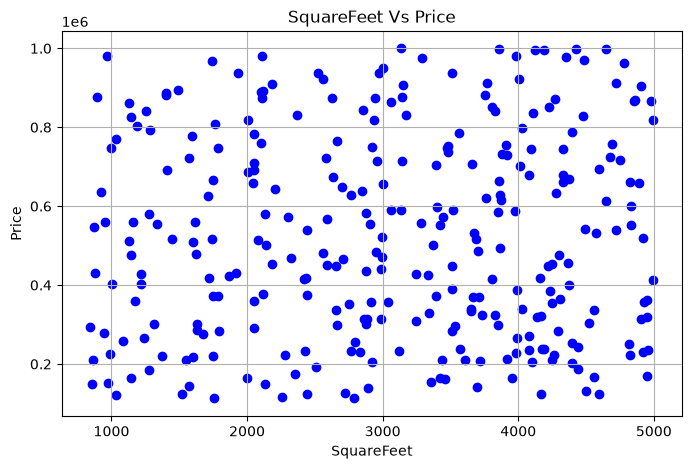

In [9]:
# Data Visualise.(Use Matplotlib)

import matplotlib.pyplot as plt

# Square feet Vs Scatter plot of price 
plt.figure(figsize=(8,5))
plt.scatter(df["SquareFeet"],df["Price"],color='blue',alpha=1)
plt.title("SquareFeet Vs Price")
plt.xlabel("SquareFeet")
plt.ylabel("Price")
plt.grid(True)
plt.show()



In [10]:
# By chart - Because there are no linear pattern for machine learning.

In [11]:
# For Scale the data - Sandard Scaler(Data generally in diffrents type of scale for Standard Scaler is used for match the scale) 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Used X - Because X is a input Data.
# fit_transform - is used for traning (for X_train). First of all it calculate the mean(average) of data and also calculate the standard deviation(Understand the layout of data), after this by use of (transform) convert to scale.
X_test_scaled = scaler.transform(X_test) # transform - it does not calculate the mean and standard deviation , it used previous mean and standard deviation ,and tranfrom data into scale.


In [12]:
# Used - Random Forest Regressor.

from sklearn.ensemble import RandomForestRegressor # To predict the random data by model.
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Random Forest Model

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train,y_train)

# Predictions
y_pred_rf =rf_model.predict(X_test)

print("Random Forest R2 Score :",round(r2_score(y_test,y_pred_rf),4))
print("Random FOrest RMSE :",round(np.sqrt(mean_squared_error(y_test,y_pred_rf)),2))



Random Forest R2 Score : -0.1053
Random FOrest RMSE : 263001.05


In [ ]:
# "Initially, we applied Linear Regression and Random Forest Regressor on the dataset. Both yielded a negative R2 score, which indicates that the dataset contains random or uncorrelated features with respect to the target variable (Price), proving that data quality and patterns are more critical than just changing algorithms."